<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Hume_Rothery_Rules_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

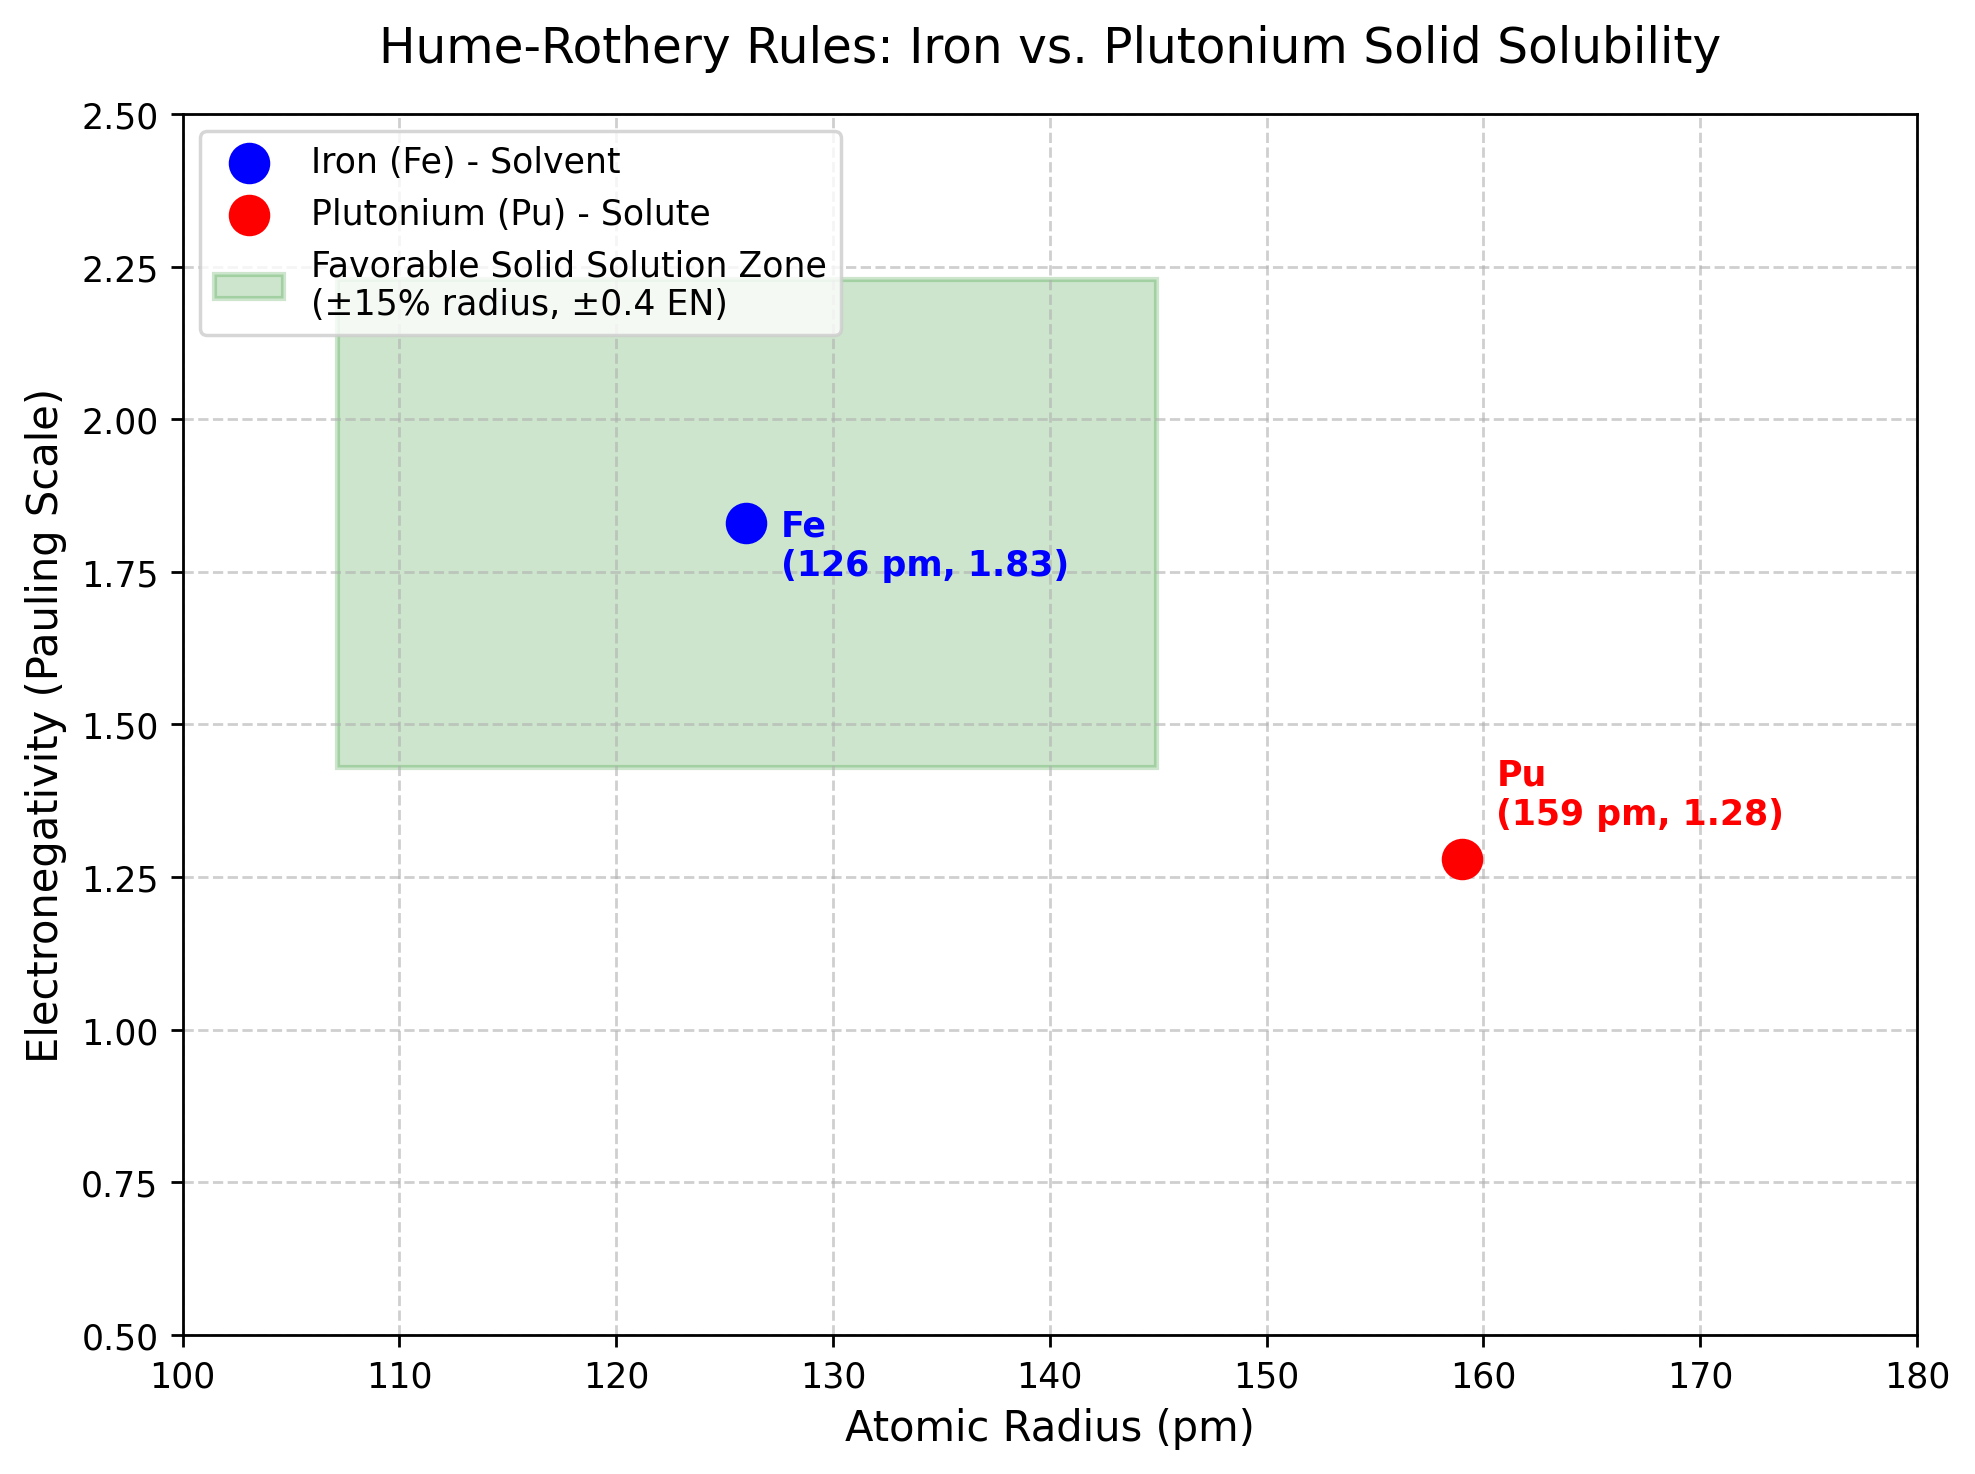

In [2]:
"""
A plot illustrating Hume-Rothery rules for Iron and Plutonium.

This script creates a 250 DPI scatter plot comparing the atomic radii and
electronegativities of Iron (Fe) and Plutonium (Pu) to determine solid
solubility based on the Hume-Rothery rules, optimized for Colab rendering.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Configure matplotlib to default to 250 DPI for inline Colab rendering
plt.rcParams['figure.dpi'] = 250

# Constants for Iron (Fe) and Plutonium (Pu) properties
RADIUS_FE = 126  # Metallic radius in pm
RADIUS_PU = 159  # Metallic radius in pm
EN_FE = 1.83     # Electronegativity (Pauling scale)
EN_PU = 1.28     # Electronegativity (Pauling scale)


def plot_hume_rothery_diagram() -> None:
    """
    Create and display a scatter plot of the Hume-Rothery favorable zone.

    Calculates the favorable solid solution zone for Iron as the solvent
    and plots Plutonium as the solute to visualize their compatibility.
    Renders the resulting plot inline for notebook environments.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot elements
    ax.scatter(
        RADIUS_FE, EN_FE, color='blue', s=120, zorder=5,
        label='Iron (Fe) - Solvent'
    )
    ax.scatter(
        RADIUS_PU, EN_PU, color='red', s=120, zorder=5,
        label='Plutonium (Pu) - Solute'
    )

    # Calculate the Hume-Rothery favorable solid solution zone for Iron
    # +/- 15% of atomic radius
    r_min = RADIUS_FE * 0.85
    r_max = RADIUS_FE * 1.15

    # Electronegativity (within ~0.4 difference preferred)
    en_min = EN_FE - 0.4
    en_max = EN_FE + 0.4

    # Create a rectangle representing the favorable solid solubility zone
    favorable_zone = patches.Rectangle(
        (r_min, en_min),
        r_max - r_min,
        en_max - en_min,
        linewidth=1.5,
        edgecolor='green',
        facecolor='green',
        alpha=0.2,
        label='Favorable Solid Solution Zone\n(±15% radius, ±0.4 EN)'
    )
    ax.add_patch(favorable_zone)

    # Annotations
    ax.annotate(
        'Fe\n(126 pm, 1.83)',
        (RADIUS_FE, EN_FE),
        xytext=(10, -15),
        textcoords='offset points',
        fontsize=10,
        weight='bold',
        color='blue'
    )
    ax.annotate(
        'Pu\n(159 pm, 1.28)',
        (RADIUS_PU, EN_PU),
        xytext=(10, 10),
        textcoords='offset points',
        fontsize=10,
        weight='bold',
        color='red'
    )

    # Formatting
    ax.set_xlim(100, 180)
    ax.set_ylim(0.5, 2.5)
    ax.set_xlabel('Atomic Radius (pm)', fontsize=12)
    ax.set_ylabel('Electronegativity (Pauling Scale)', fontsize=12)
    ax.set_title(
        'Hume-Rothery Rules: Iron vs. Plutonium Solid Solubility',
        fontsize=14,
        pad=15
    )
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper left', frameon=True)

    plt.tight_layout()
    # Render inline instead of saving to disk
    plt.show()


if __name__ == "__main__":
    plot_hume_rothery_diagram()